In [11]:
from pathlib import Path
image_folder = Path(r"Data/Patient acquired images/")
print("Folder found:", image_folder.is_dir())

Folder found: True


In [12]:
from PIL import Image
images = []
for path in image_folder.rglob("*"):
    if path.is_file() and path.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}:
        with Image.open(path) as img:
            images.append(img.copy())

print("Images loaded:", len(images))

Images loaded: 132


There are 132 Patient-acquired raw images in the dataset without any re-sampling or data augmentation. AI generated synthetic images are yet to be added. 

In [13]:
import numpy as np
import pandas as pd

image_info = pd.DataFrame([ {"image_number": i + 1,
                             "width": img.width,
                             "height": img.height,
                             "channels": len(img.getbands()),
                             "mode": img.mode,
                             "pixel_data_type": str(np.asarray(img).dtype),
                             "pixel_values": np.asarray(img).size}
    for i, img in enumerate(images)
])

print("Number of images:", len(images))
print("Image features: pixel values")
print("Features per image = width × height × channels")

display(image_info.head())
display(image_info.dtypes)

Number of images: 132
Image features: pixel values
Features per image = width × height × channels


,image_number,width,height,channels,mode,pixel_data_type,pixel_values
0,1,1200,1600,3,RGB,uint8,5760000
1,2,1200,1600,3,RGB,uint8,5760000
2,3,1200,1600,3,RGB,uint8,5760000
3,4,1200,1600,3,RGB,uint8,5760000
4,5,1200,1600,3,RGB,uint8,5760000


image_number        int64
width               int64
height              int64
channels            int64
mode               object
pixel_data_type    object
pixel_values        int64
dtype: object

These are raw images, not preprocessed or cleaned. Data regarding these images have been showed. 

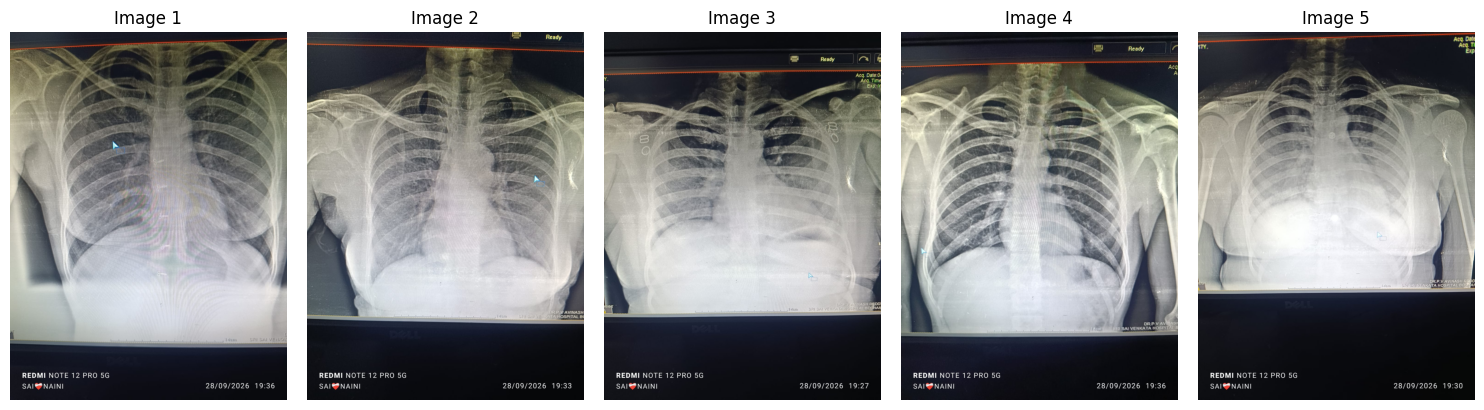

In [14]:
import matplotlib.pyplot as plt

sample_count = min(5, len(images))

if sample_count > 0:
    fig, axes = plt.subplots(1, sample_count, figsize=(15, 4), squeeze=False)

    for i in range(sample_count):
        axes[0, i].imshow(images[i], cmap="gray")
        axes[0, i].set_title(f"Image {i + 1}")
        axes[0, i].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No images loaded.")

These are few samples of the patient-acquired raw images. 

Creating .gitignore file 

In [23]:
from pathlib import Path

gitignore = Path(".gitignore")

with gitignore.open("a") as file:
    file.write("\ndata/\n")

print("Created at:", gitignore.resolve())

Created at: /home/vsarasani/Ray Verify/.gitignore


In [24]:
from pathlib import Path
file = Path("/home/vsarasani/Ray Verify/.gitignore")
print("Exists:", file.is_file())
print("Contents:", file.read_text())

Exists: True
Contents: data/

data/



I created the file .gitignore but it is not being shown 